In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt

## Load Data

In [2]:
adata = ad.read_h5ad("./data/adata_cleaned.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 2092 × 14046
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id_snp', 'hashedDrops_Best', 'hashedDrops_Second', 'hashedDrops_LogFC', 'hashedDrops_LogFC2', 'hashedDrops_Doublet', 'hashedDrops_Confident', 'hashedDrops_classification', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Donor_ID_HTOdemux_localSNP', 'Timepoint', 'tetramer_batch', 'dosage', 'HTO_SNP_agreed_donor', 'S.Score', 'G2M.Score', 'Phase', 'latent_donor', 'latent_HTO', 'sort_person', 'GEM_date', 'library_prep_date', 'GEM_storage_day', 'GEM_prep_person', 'PCR_cycle', 'Donor_ID_conservative', 'RNA_snn_res.0.5', 'seurat_clusters', 'donor_1pct', 'donor_hybrid', 'sample', 'condition', 'TCR_alpha1', 'TCR_alpha2', 'TCR_beta', 'V_alpha1', 'J_alpha1', 'C_alpha1', 'V_beta', 'J_beta', 'C_beta', 'nCount_SCT', 'nFeature_SCT', 'clusters_UMAP', 'RNA_snn_res.0.8', 'Naive_pos', 'Naive_neg'

## Heatmap top 12 Genes per cluster

In [4]:
adata.X = adata.layers['logcounts']
sc.pp.scale(adata)
adata.layers['zscore'] = adata.X

/usr/local/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
adata.X = adata.layers['raw_count']

In [7]:
sc.tl.rank_genes_groups(adata, groupby="seurat_clusters", method="wilcoxon",layer="logcounts")

/home/mbrochut@ad.unil.ch/Documents/programmation/single_cell_HIV/env_hiv/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 14046 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


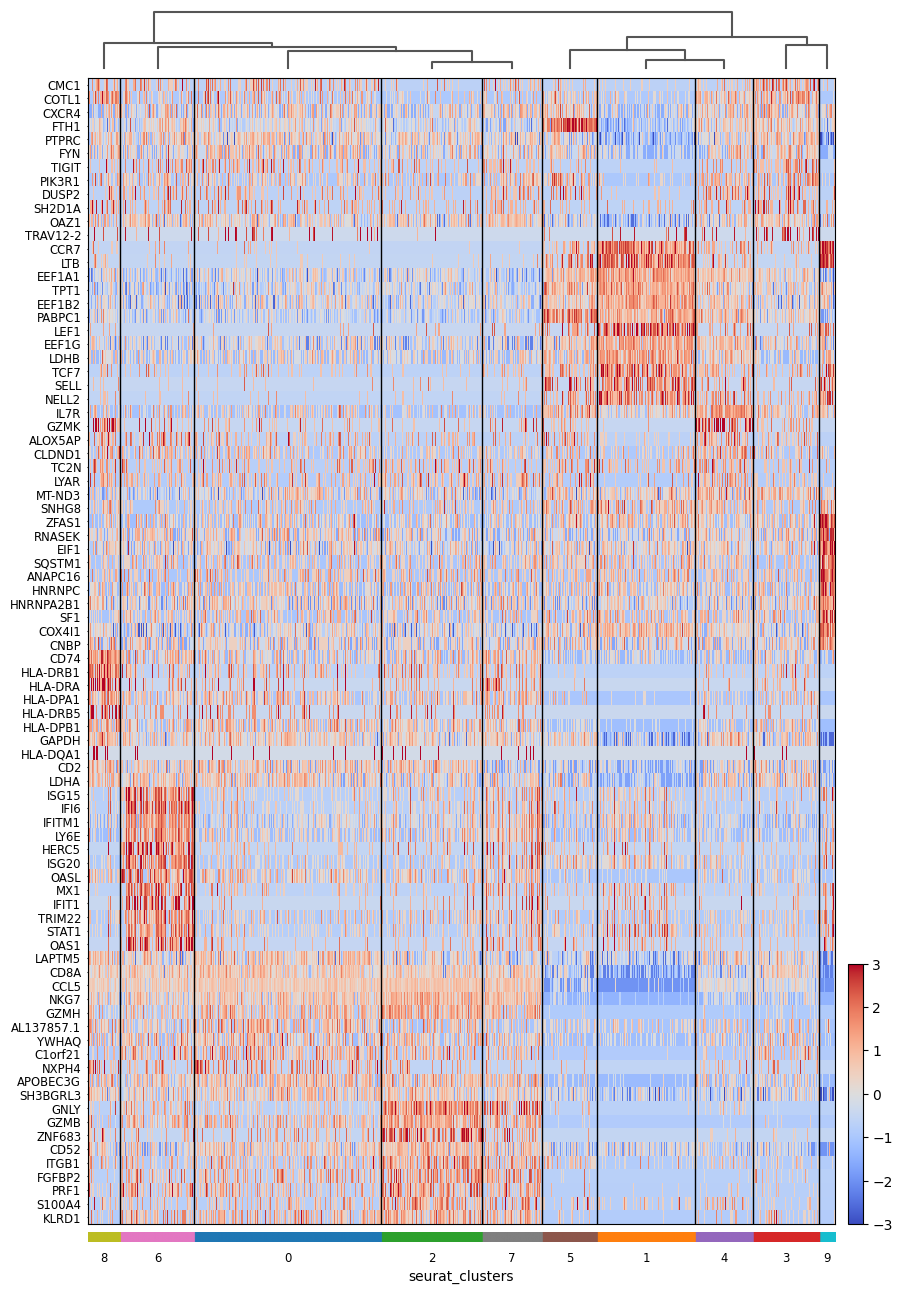

In [ ]:
# Desired cluster order
cluster_order = ['3', '1', '4', '9', '8', '6', '0', '2']

# Get top 12 genes per cluster in desired order
ranked_genes = adata.uns['rank_genes_groups']
top_genes_ordered = []

for cluster in cluster_order:
    top = pd.DataFrame({
        'names': ranked_genes['names'][cluster]
    }).head(12)['names'].values
    top_genes_ordered.extend(top)

unique_top_genes = list(dict.fromkeys(top_genes_ordered))  # preserves order

# Plot heatmap
sc.pl.heatmap(
    adata,
    var_names=unique_top_genes,
    groupby='seurat_clusters',
    swap_axes=True,       
    dendrogram=True,             
    figsize=(10, 16),
    show=True,
    show_gene_labels = True,
    cmap='coolwarm',
    save='top12_genes_zscore.png',
    layer='zscore',
    vmin=-3,
    vmax=3
)

## Heatmaps clutser 5 DEG

In [9]:
adata

AnnData object with n_obs × n_vars = 2092 × 14046
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id_snp', 'hashedDrops_Best', 'hashedDrops_Second', 'hashedDrops_LogFC', 'hashedDrops_LogFC2', 'hashedDrops_Doublet', 'hashedDrops_Confident', 'hashedDrops_classification', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Donor_ID_HTOdemux_localSNP', 'Timepoint', 'tetramer_batch', 'dosage', 'HTO_SNP_agreed_donor', 'S.Score', 'G2M.Score', 'Phase', 'latent_donor', 'latent_HTO', 'sort_person', 'GEM_date', 'library_prep_date', 'GEM_storage_day', 'GEM_prep_person', 'PCR_cycle', 'Donor_ID_conservative', 'RNA_snn_res.0.5', 'seurat_clusters', 'donor_1pct', 'donor_hybrid', 'sample', 'condition', 'TCR_alpha1', 'TCR_alpha2', 'TCR_beta', 'V_alpha1', 'J_alpha1', 'C_alpha1', 'V_beta', 'J_beta', 'C_beta', 'nCount_SCT', 'nFeature_SCT', 'clusters_UMAP', 'RNA_snn_res.0.8', 'Naive_pos', 'Naive_neg'

In [10]:
cluster_5_DEG = pd.read_csv("./data/DEG_cluster5.csv")

In [11]:
list_of_interest = cluster_5_DEG['gene'].tolist()

In [12]:
adata_cluster_5 = adata[adata.obs['seurat_clusters']=='5']

In [13]:
adata_cluster_5.obs['expanded'] = adata_cluster_5.obs['expanded'].replace('Single','Other')

/tmp/ipykernel_1867049/242504825.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_cluster_5.obs['expanded'] = adata_cluster_5.obs['expanded'].replace('Single','Other')
/tmp/ipykernel_1867049/242504825.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cluster_5.obs['expanded'] = adata_cluster_5.obs['expanded'].replace('Single','Other')


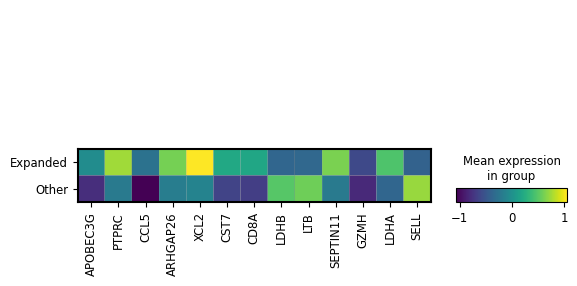

In [14]:
sc.pl.matrixplot(adata_cluster_5,var_names=list_of_interest,groupby='expanded',layer='zscore',save='mean_expressionZscore_DEG_cluster5.png')